# EDA — the seven fields and the label

`train.ipynb` builds the model. This notebook looks at the data underneath it:
what the seven `ml/v14` fields contain, how they relate to each other, and how
much each one tells you about the label.

**The label is `not_benign`** — 0 for a Benign Positive the AI can close, 1 for
anything else.

| Field | What it is |
| --- | --- |
| `rule_name` | which detection fired |
| `rule_title` | the detection's headline |
| `search_name` | the saved search wrapping the rule |
| `security_domain` | threat / access / audit / endpoint |
| `rule_description` | what the detection looks for — static per rule |
| `severity` | the detection's own severity |
| `ClientName` | which customer |

Plus the six non-identity entity types v13/v14 use: `IPV4` `IPV6` `URL`
`FILEPATH` `FILENAME` `HASH`.

The last section is different in kind: it leaves the input behind and walks
through **how the operating threshold is chosen** — the one number that turns
a score into a lane — in six figures.

Kernel: **AI-SOC training pipeline**.

In [1]:
%matplotlib inline
import collections, gzip, json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ML = Path.cwd().parent
sys.path.insert(0, str(ML))
import dataset12 as D12

pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 60)

FIELDS = ["rule_name", "rule_title", "search_name", "security_domain",
          "rule_description", "severity", "ClientName"]
ENTITIES = ["IPV4", "IPV6", "URL", "FILEPATH", "FILENAME", "HASH"]
TARGET = "not_benign"

print("source:", D12.SOURCE.name)

source: soar-containers-12mo-20260923.jsonl.gz


## Load the seven fields, raw

Not the rendered `key value` text the model sees — the **raw values**, so each
field can be treated as a categorical variable.

In [2]:
rows = []
with gzip.open(D12.SOURCE, "rt") as fh:
    for line in fh:
        rec = json.loads(line)
        if rec.get("disposition") not in D12.KEEP:
            continue
        notable = next((o for o in D12.artifacts(rec.get("CEF") or [])
                        if D12.is_notable(o)), None)
        if notable is None:
            continue
        row = {"container_id": f"{rec['server']}:{rec['id']}",
               "t": rec.get("close_time"),
               "verdict": D12.KEEP[rec["disposition"]]}
        for f in FIELDS:
            v = D12.flatten(notable.get(f)).strip()
            row[f] = v if v and v.lower() not in ("none", "null", "-", "unknown") else None
        rows.append(row)

d = pd.DataFrame(rows)
d["t"] = pd.to_datetime(d["t"], utc=True)
d[TARGET] = (d["verdict"] != "Benign Positive").astype(int)
d = d.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

# entity presence, from the frozen NER run
ent = pd.read_csv(ML / "training-data" / "entities.csv",
                  usecols=["container_id"] + [f"hi_{e}" for e in ENTITIES])
for e in ENTITIES:
    ent[f"has_{e}"] = ent[f"hi_{e}"].notna() & (ent[f"hi_{e}"].astype(str).str.len() > 0)
d = d.merge(ent[["container_id"] + [f"has_{e}" for e in ENTITIES]],
            on="container_id", how="left")
for e in ENTITIES:
    d[f"has_{e}"] = d[f"has_{e}"].fillna(False).astype(int)

print(f"{len(d):,} alerts   {d[TARGET].mean()*100:.1f}% not benign")
print(f"span {d.t.min():%Y-%m-%d} → {d.t.max():%Y-%m-%d}")
d[FIELDS + [TARGET]].head(3)

30,828 alerts   18.9% not benign
span 2025-10-08 → 2026-09-22


,rule_name,rule_title,search_name,security_domain,rule_description,severity,ClientName,not_benign
0,Authentication - Basic Brute Force Detection - Windows,Basic Brute Force Detection - Windows $sourceHostName$ t...,Threat - Authentication - Basic Brute Force Detection - ...,threat,Detected an excessive number of failed login attempt fol...,high,NaN,0
1,LSU - Defender - New High Severity Alerts,New High Severity Alerts - $title$ - $user$ - $IOC$,Threat - LSU - Defender - New High Severity Alerts - Rule,threat,This search looks for high severity alerts from MS Defen...,high,NaN,1
2,Audit - TS - Azure - App Role Assignment Grants to User ...,Audit - TS - Azure - App Role Assignment Grants to User ...,Audit - TS - Azure - App Role Assignment Grants to User\...,threat,NaN,NaN,NaN,0


## What is in each field

Cardinality matters for what follows: a field with 4 values and a field with
3,000 tell you very different things, and most association measures are biased
upward by high cardinality.

In [3]:
prof = pd.DataFrame([{
    "field": f,
    "present_pct": round(d[f].notna().mean() * 100, 1),
    "distinct": d[f].nunique(),
    "top_value": (d[f].mode().iloc[0][:44] if d[f].notna().any() else "—"),
    "top_share_pct": round(d[f].value_counts(normalize=True).iloc[0] * 100, 1)
                     if d[f].notna().any() else 0.0,
} for f in FIELDS]).sort_values("distinct")
prof

,field,present_pct,distinct,top_value,top_share_pct
5,severity,97.3,5,high,41.3
3,security_domain,100.0,6,threat,40.1
6,ClientName,42.4,50,LSUA,8.3
0,rule_name,100.0,431,TS - Defender - DEF07 - New High Severity Al,8.8
2,search_name,100.0,431,Threat - TS - Defender - DEF07 - New High Se,8.8
1,rule_title,100.0,561,$ClientName$ - TS - Defender - DEF07 - New H,8.8
4,rule_description,98.4,2615,This search looks for high severity alerts f,8.9


## The label, by field value

Before any correlation number — the thing itself. How does the not-benign rate
move across the values of each field?

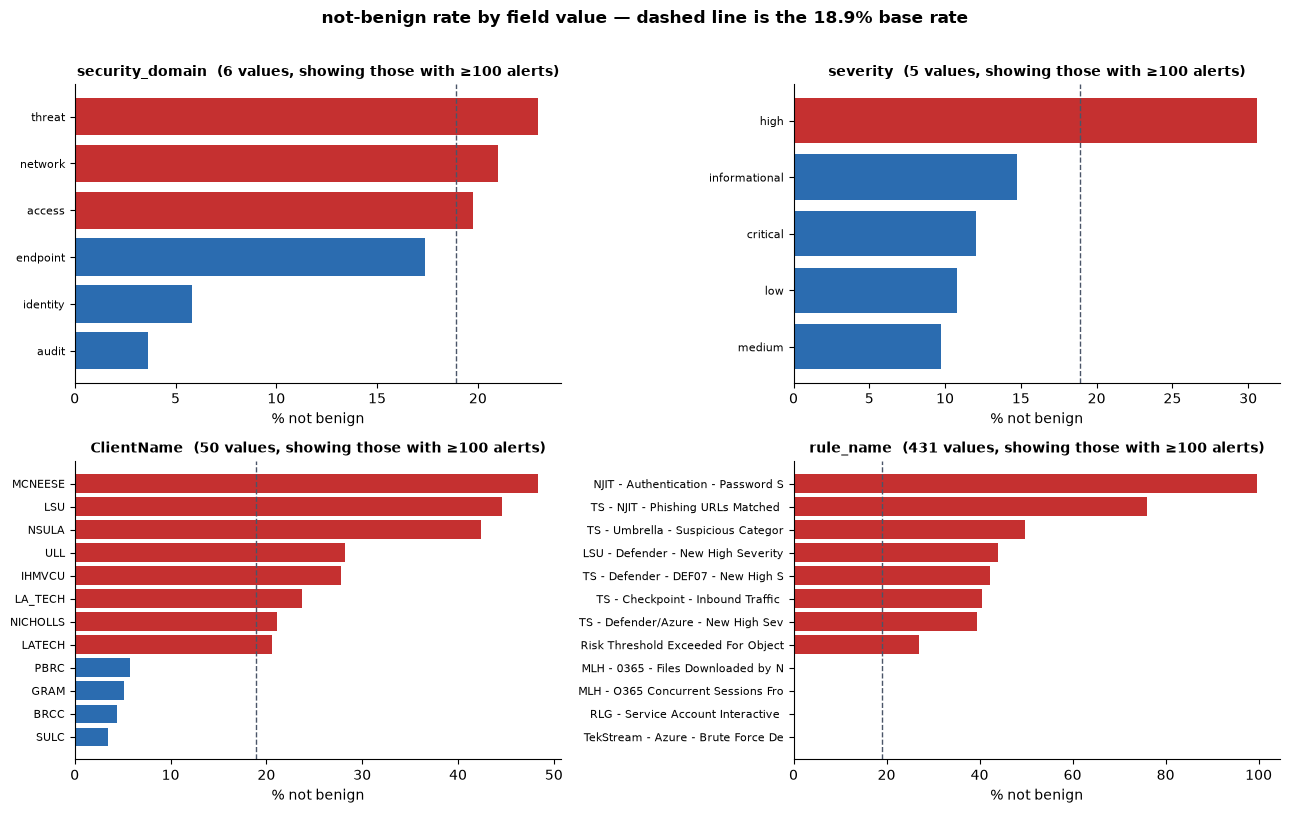

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
base = d[TARGET].mean() * 100

for ax, f in zip(axes.ravel(), ["security_domain", "severity", "ClientName", "rule_name"]):
    g = (d.groupby(f)[TARGET].agg(["size", "mean"])
           .query("size >= 100").sort_values("mean", ascending=False))
    g = pd.concat([g.head(8), g.tail(4)]) if len(g) > 12 else g
    colors = ["#c53030" if m * 100 > base else "#2b6cb0" for m in g["mean"]]
    ax.barh(range(len(g)), g["mean"] * 100, color=colors)
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([str(i)[:34] for i in g.index], fontsize=8)
    ax.invert_yaxis()
    ax.axvline(base, color="#4a5568", ls="--", lw=1)
    ax.set_xlabel("% not benign")
    ax.set_title(f"{f}  ({d[f].nunique():,} values, showing those with ≥100 alerts)",
                 fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"not-benign rate by field value — dashed line is the {base:.1f}% base rate",
             fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout(); plt.show()

---
# The correlation matrix

**These are categorical fields, so Pearson correlation does not apply.** There is
no meaningful ordering to `rule_name`, and no distance between one rule and
another. The right measure is **Cramér's V**, which is built on the chi-squared
statistic of a contingency table and runs 0 (independent) to 1 (one field fully
determines the other).

Two things to hold on to when reading it:

- **V is biased upward by cardinality.** A field with 3,000 values will score
  higher against anything than a field with 4, because it has more room to carve
  up the table. The bias-corrected version below reduces that but does not
  remove it.
- **V is symmetric and undirected.** It says two fields move together, not that
  one predicts the other.

In [5]:
def cramers_v(a, b):
    """Bias-corrected Cramér's V between two categorical series."""
    pair = pd.DataFrame({"a": a, "b": b}).dropna()
    if pair.empty or pair["a"].nunique() < 2 or pair["b"].nunique() < 2:
        return np.nan
    table = pd.crosstab(pair["a"], pair["b"]).to_numpy()
    n = table.sum()
    expected = np.outer(table.sum(1), table.sum(0)) / n
    chi2 = ((table - expected) ** 2 / np.where(expected == 0, np.nan, expected))
    chi2 = np.nansum(chi2)
    phi2 = chi2 / n
    r, k = table.shape
    # Bergsma-Wicher correction for the cardinality bias
    phi2 = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_ = r - (r - 1) ** 2 / (n - 1)
    k_ = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_ - 1, r_ - 1)
    return float(np.sqrt(phi2 / denom)) if denom > 0 else np.nan


cols = FIELDS + [TARGET]
V = pd.DataFrame(index=cols, columns=cols, dtype=float)
for i in cols:
    for j in cols:
        V.loc[i, j] = 1.0 if i == j else cramers_v(d[i], d[j])
V.round(3)

,rule_name,rule_title,search_name,security_domain,rule_description,severity,ClientName,not_benign
rule_name,1.000,0.982,0.988,0.990,0.823,0.891,0.495,0.582
rule_title,0.982,1.000,0.984,0.987,0.728,0.897,0.515,0.589
search_name,0.988,0.984,1.000,0.991,0.826,0.891,0.513,0.582
security_domain,0.990,0.987,0.991,1.000,0.915,0.251,0.505,0.149
rule_description,0.823,0.728,0.826,0.915,1.000,0.840,0.506,0.560
severity,0.891,0.897,0.891,0.251,0.840,1.000,0.522,0.256
ClientName,0.495,0.515,0.513,0.505,0.506,0.522,1.000,0.355
not_benign,0.582,0.589,0.582,0.149,0.560,0.256,0.355,1.000


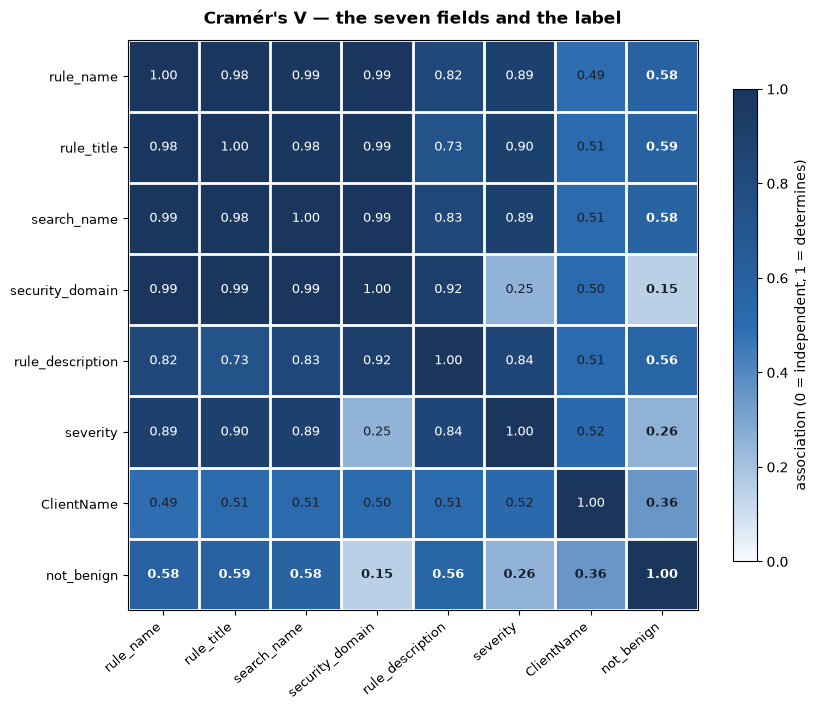

In [6]:
BLUE = LinearSegmentedColormap.from_list("b", ["#f7fbff", "#2b6cb0", "#1a365d"])
fig, ax = plt.subplots(figsize=(8.6, 7.2))
im = ax.imshow(V.astype(float), cmap=BLUE, vmin=0, vmax=1)

for i in range(len(cols)):
    for j in range(len(cols)):
        v = V.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9.5,
                    fontweight="bold" if (cols[i] == TARGET or cols[j] == TARGET) else "normal",
                    color="white" if v > 0.55 else "#1a202c")

ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(cols, fontsize=9)
ax.set_xticks(np.arange(-.5, len(cols), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(cols), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
ax.set_title("Cramér's V — the seven fields and the label",
             fontsize=12, fontweight="bold", pad=12)
fig.colorbar(im, ax=ax, shrink=0.8, label="association (0 = independent, 1 = determines)")
fig.tight_layout(); plt.show()

## The row that answers the question

The last row and column are the label. Everything else is the fields against each
other — which is worth reading too, because several of them are near-duplicates.

In [7]:
lab = (V[TARGET].drop(TARGET).sort_values(ascending=False)
       .rename("cramers_v").to_frame())
lab["distinct_values"] = [d[f].nunique() for f in lab.index]
lab["coverage_pct"] = [round(d[f].notna().mean() * 100, 1) for f in lab.index]
lab.round(3)

,cramers_v,distinct_values,coverage_pct
rule_title,0.589,561,100.0
rule_name,0.582,431,100.0
search_name,0.582,431,100.0
rule_description,0.560,2615,98.4
ClientName,0.355,50,42.4
severity,0.256,5,97.3
security_domain,0.149,6,100.0


### Mutual information, as a second opinion

Cramér's V rewards cardinality. **Mutual information** measures how many bits of
the label a field actually resolves, and `normalized MI` divides by the label's
own entropy — so it reads directly as *"this field explains N% of the uncertainty
in the label"*. Where the two measures disagree, MI is the more honest one for
"how useful is this field".

In [8]:
from sklearn.metrics import mutual_info_score

H_label = -sum(p * np.log(p) for p in d[TARGET].value_counts(normalize=True))
mi = pd.DataFrame([{
    "field": f,
    "mutual_info_bits": mutual_info_score(d[f].fillna("(missing)"), d[TARGET]),
    "normalized_MI_pct": mutual_info_score(d[f].fillna("(missing)"), d[TARGET]) / H_label * 100,
    "distinct": d[f].nunique(),
} for f in FIELDS]).sort_values("normalized_MI_pct", ascending=False).reset_index(drop=True)
mi.round(3)

,field,mutual_info_bits,normalized_MI_pct,distinct
0,rule_description,0.193,39.819,2615
1,rule_title,0.177,36.432,561
2,rule_name,0.170,35.033,431
3,search_name,0.170,34.967,431
4,severity,0.032,6.691,5
5,ClientName,0.026,5.318,50
6,security_domain,0.014,2.988,6


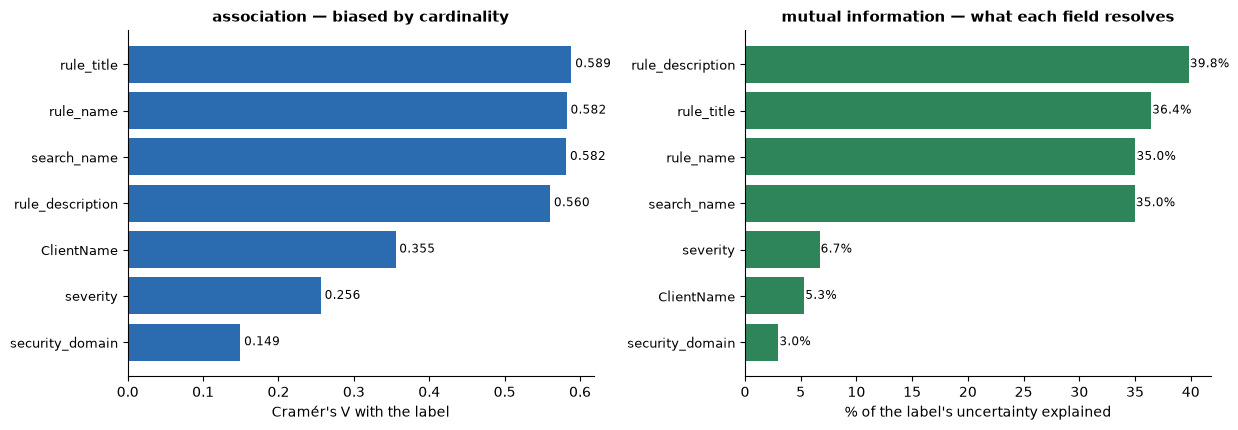

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

o = lab.sort_values("cramers_v")
ax1.barh(range(len(o)), o["cramers_v"], color="#2b6cb0")
ax1.set_yticks(range(len(o))); ax1.set_yticklabels(o.index, fontsize=9)
ax1.set_xlabel("Cramér's V with the label")
ax1.set_title("association — biased by cardinality", fontsize=11, fontweight="bold")
for i, v in enumerate(o["cramers_v"]):
    ax1.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8.5)
ax1.spines[["top", "right"]].set_visible(False)

o2 = mi.sort_values("normalized_MI_pct")
ax2.barh(range(len(o2)), o2["normalized_MI_pct"], color="#2f855a")
ax2.set_yticks(range(len(o2))); ax2.set_yticklabels(o2["field"], fontsize=9)
ax2.set_xlabel("% of the label's uncertainty explained")
ax2.set_title("mutual information — what each field resolves",
              fontsize=11, fontweight="bold")
for i, v in enumerate(o2["normalized_MI_pct"]):
    ax2.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8.5)
ax2.spines[["top", "right"]].set_visible(False)

fig.tight_layout(); plt.show()

---
## The entities

Six binary indicators — does this alert contain at least one entity of that type.
Binary against binary, so the **phi coefficient** applies, which here is just
Pearson on two 0/1 variables and is directly comparable to an ordinary
correlation.

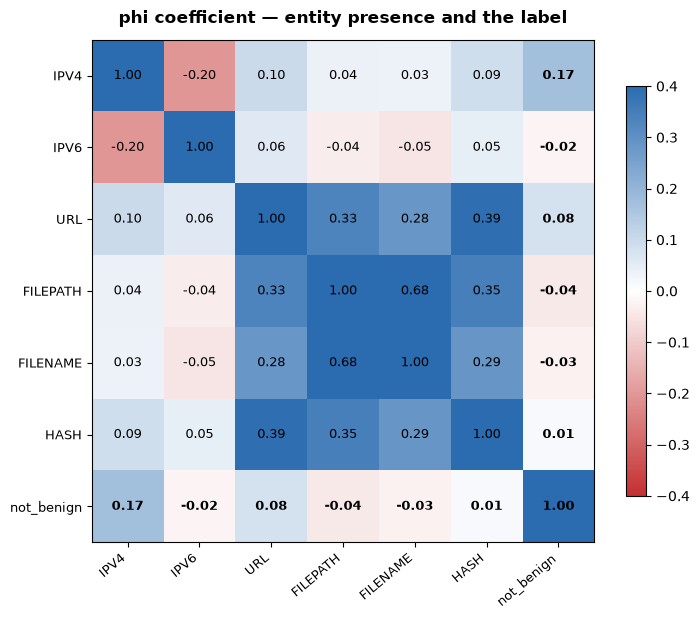

not-benign rate when the entity type is present vs absent:

  entity       present    absent    lift   on alerts
  IPV4           25.3%     11.7%  +13.6pp       53.4%
  IPV6           15.6%     19.1%   -3.5pp        5.4%
  URL            27.4%     17.8%   +9.7pp       12.1%
  FILEPATH       13.2%     19.4%   -6.2pp        7.7%
  FILENAME       14.2%     19.1%   -5.0pp        4.3%
  HASH           20.1%     18.7%   +1.4pp       16.1%


In [10]:
ecols = [f"has_{e}" for e in ENTITIES]
phi = d[ecols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(7.4, 6.2))
RB = LinearSegmentedColormap.from_list("rb", ["#c53030", "#ffffff", "#2b6cb0"])
im = ax.imshow(phi, cmap=RB, vmin=-0.4, vmax=0.4)
labels = ENTITIES + ["not_benign"]
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{phi.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold" if labels[i] == "not_benign" or labels[j] == "not_benign" else "normal")
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_title("phi coefficient — entity presence and the label",
             fontsize=12, fontweight="bold", pad=12)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); plt.show()

print("not-benign rate when the entity type is present vs absent:\n")
print(f"  {'entity':10s} {'present':>9s} {'absent':>9s} {'lift':>7s} {'on alerts':>11s}")
for e in ENTITIES:
    p = d.loc[d[f"has_{e}"] == 1, TARGET].mean() * 100
    a = d.loc[d[f"has_{e}"] == 0, TARGET].mean() * 100
    print(f"  {e:10s} {p:8.1f}% {a:8.1f}% {p-a:+6.1f}pp {d[f'has_{e}'].mean()*100:10.1f}%")

---
## The base rate is not stationary

Worth seeing before trusting any of the above: the label itself moves a great
deal across the window. This is why the pipeline scrubs every date out of the
input and splits forward on decision time rather than shuffling.

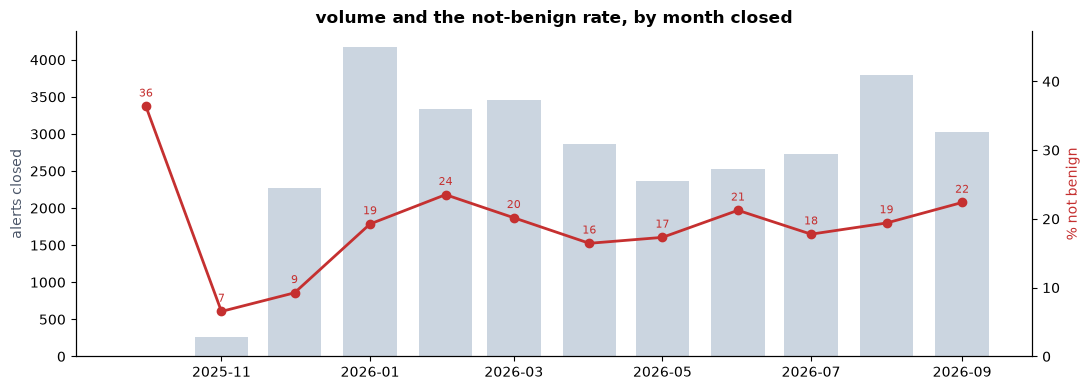

,alerts,not_benign_rate
t,,
2025-10-01 00:00:00+00:00,11,36.4
2025-11-01 00:00:00+00:00,260,6.5
2025-12-01 00:00:00+00:00,2271,9.2
2026-01-01 00:00:00+00:00,4175,19.3
2026-02-01 00:00:00+00:00,3342,23.5
2026-03-01 00:00:00+00:00,3462,20.2
2026-04-01 00:00:00+00:00,2870,16.4
2026-05-01 00:00:00+00:00,2363,17.3
2026-06-01 00:00:00+00:00,2523,21.2


In [11]:
m = d.set_index("t")[TARGET].resample("MS").agg(["size", "mean"])
m.columns = ["alerts", "not_benign_rate"]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(m.index, m["alerts"], width=22, color="#cbd5e0", label="alerts")
ax1.set_ylabel("alerts closed", color="#4a5568")
ax2 = ax1.twinx()
ax2.plot(m.index, m["not_benign_rate"] * 100, marker="o", color="#c53030",
         lw=2, label="% not benign")
ax2.set_ylabel("% not benign", color="#c53030")
ax2.set_ylim(0, max(m["not_benign_rate"]) * 130)
for x, y in zip(m.index, m["not_benign_rate"] * 100):
    ax2.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 7),
                 ha="center", fontsize=8, color="#c53030")
ax1.set_title("volume and the not-benign rate, by month closed",
              fontsize=12, fontweight="bold")
ax1.spines[["top"]].set_visible(False); ax2.spines[["top"]].set_visible(False)
fig.tight_layout(); plt.show()
m.assign(not_benign_rate=lambda x: (x.not_benign_rate * 100).round(1))

---
# Reading all of this together

A high association score is **not** a promise of model performance. `rule_name`
has thousands of values, so it can carve the label finely on the data it has
seen — and that is exactly the behaviour that fails on a rule it has never seen
before. The forward split in `train.ipynb` is what keeps that honest; nothing on
this page does.

The reverse also holds. `security_domain` has a handful of values and a low
association score, but it is on 100% of alerts and never goes stale, so it costs
nothing to carry.

**What this page is good for:** spotting a field that is nearly constant, two
fields that are near-duplicates of each other, or a label that moves with the
calendar. All three are visible above.

**What it is not good for:** choosing features. That is what the out-of-fold
measurements in `train.ipynb` are for, and where every version decision in this
project was actually made.

---
# How the operating threshold is chosen

Everything above is about the *input*. This last section is about the one number
that turns a score into a decision.

The model does not output "benign" or "not benign". It outputs a score between 0
and 1, and a single line through that score decides the lane:

| | |
| --- | --- |
| `score < threshold` | **AI lane** — auto-closed, no human ever sees it |
| `score >= threshold` | **human lane** — an analyst works it |

So the threshold *is* the risk appetite. Move it right and more alerts close
themselves and more mistakes escape; move it left and analysts do work they did
not need to do. Nothing about this number is learned during training — the model
is already frozen when it is chosen, and changing it retrains nothing.

The obvious way to pick it is to sort the scores, walk up from the bottom, and
cut where the first not-benign alert appears. **That is the trap this section is
about.** The four steps below are what `calibrate.py` actually does instead.


## Step 0 — three windows, in time order

The threshold cannot be chosen on data the model was fitted on: those scores are
optimistic, and a line drawn through them is drawn through memorised answers. So
the tail of the corpus is cut into three, forward in time:

* **train** — the model is fitted here, and never sees the rest
* **calibrate** — the threshold is *chosen* here, on scores from unseen alerts
* **validate** — the threshold is *tested* here, on alerts the choosing never saw

The validate window is the honest one. Everything reported to a customer comes
from it.


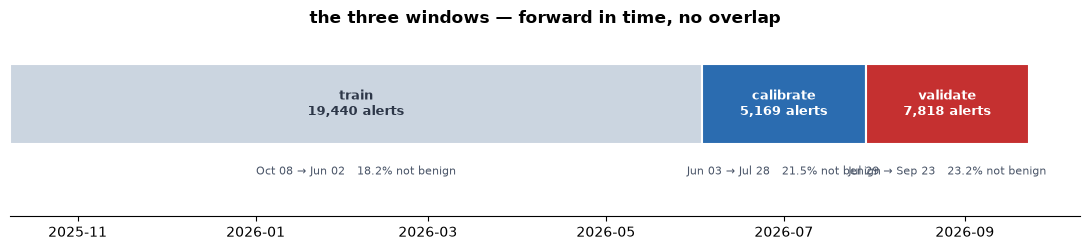

release v20   min_df 1   confidence 95%   tolerance 1.0%


In [12]:
import sys
from pathlib import Path

import yaml
from scipy.stats import beta

import calibrate as CAL
import freeze as FZ

WEEKS       = 8          # width of the calibrate and validate windows
TOLERANCE   = 0.01       # declared risk appetite: 1% AI-lane error rate
CONFIDENCE  = 0.95
COLUMN      = "text_v20" # the shipped release

frame = pd.read_parquet(FZ.DATASETS[COLUMN]).sort_values("t").reset_index(drop=True)
end      = frame["t"].max()
cal_from = end - pd.Timedelta(weeks=2 * WEEKS)
val_from = end - pd.Timedelta(weeks=WEEKS)

train = frame[frame["t"] < cal_from]
calw  = frame[(frame["t"] >= cal_from) & (frame["t"] < val_from)]
valw  = frame[frame["t"] >= val_from]

model = CAL.fit(train, COLUMN, FZ.MIN_DF[COLUMN])
s_cal, y_cal = model.predict_proba(calw[[COLUMN]])[:, 1], calw.y_human.to_numpy()
s_val, y_val = model.predict_proba(valw[[COLUMN]])[:, 1], valw.y_human.to_numpy()

fig, ax = plt.subplots(figsize=(11, 2.6))
parts = [("train",     train, "#cbd5e0", "fitted here"),
         ("calibrate", calw,  "#2b6cb0", "threshold chosen here"),
         ("validate",  valw,  "#c53030", "threshold tested here")]
for i, (name, part, colour, note) in enumerate(parts):
    lo, hi = part.t.min(), part.t.max()
    ax.barh(0, hi - lo, left=lo, height=0.5, color=colour,
            edgecolor="white", linewidth=1.5)
    mid = lo + (hi - lo) / 2
    ax.text(mid, 0, f"{name}\n{len(part):,} alerts", ha="center", va="center",
            color="white" if i else "#2d3748", fontsize=9, fontweight="bold")
    ax.text(mid, -0.42, f"{lo:%b %d} → {hi:%b %d}   {part.y_human.mean()*100:.1f}% not benign",
            ha="center", va="center", fontsize=8, color="#4a5568")
ax.set_ylim(-0.7, 0.45); ax.set_yticks([])
ax.set_title("the three windows — forward in time, no overlap",
             fontsize=12, fontweight="bold")
ax.spines[["top", "left", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

print(f"release v20   min_df {FZ.MIN_DF[COLUMN]}   confidence {CONFIDENCE:.0%}   "
      f"tolerance {TOLERANCE:.1%}")


## Step 1 — sort the calibration window by score

Sorted lowest score first. Every grey dot is a Benign Positive the AI may close;
every red cross is an alert it must not. The question the threshold answers is
**how far to the right can the cut go** before too much red is behind it.

The left panel is the whole window; the right panel zooms into the bottom of it,
which is the only part that matters — everything else is far above any cut we
would ever make.


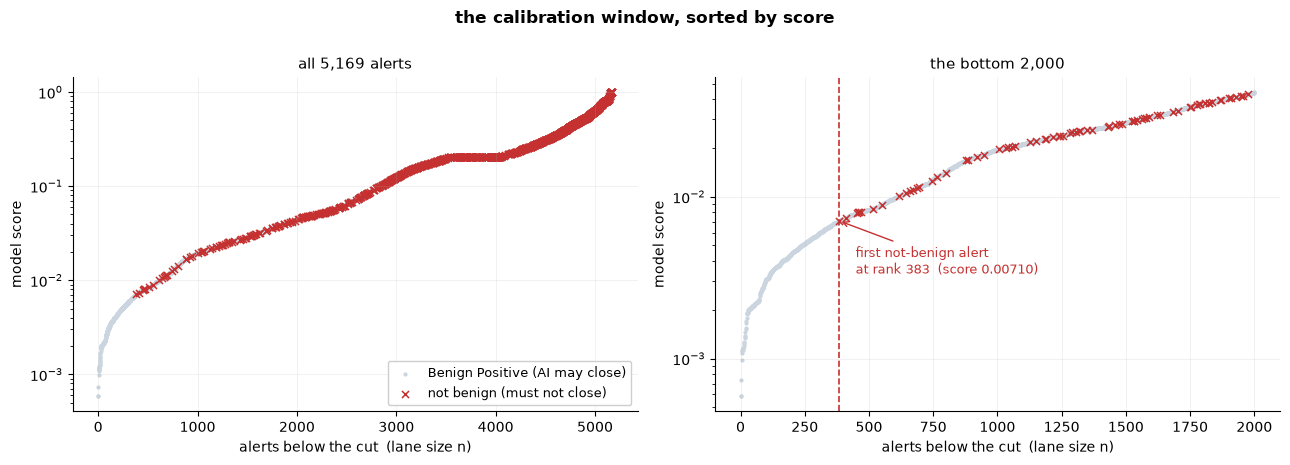

clean run before the first not-benign alert: 382 alerts (7.39% of the window)


In [13]:
order  = np.argsort(s_cal, kind="mergesort")
sy, ss = y_cal[order], s_cal[order]
rank   = np.arange(1, len(ss) + 1)
first_miss = int(np.argmax(sy == 1)) + 1        # 1-based rank of the first red

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, upto, title in ((axes[0], len(ss), f"all {len(ss):,} alerts"),
                        (axes[1], min(2000, len(ss)), "the bottom 2,000")):
    clean = sy[:upto] == 0
    ax.scatter(rank[:upto][clean], ss[:upto][clean], s=4, color="#cbd5e0",
               label="Benign Positive (AI may close)")
    ax.scatter(rank[:upto][~clean], ss[:upto][~clean], s=26, marker="x",
               color="#c53030", linewidth=1.1, label="not benign (must not close)")
    ax.set_yscale("log"); ax.set_xlabel("alerts below the cut  (lane size n)")
    ax.set_ylabel("model score")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].axvline(first_miss, color="#c53030", ls="--", lw=1.2)
axes[1].annotate(f"first not-benign alert\nat rank {first_miss:,}  (score {ss[first_miss-1]:.5f})",
                 xy=(first_miss, ss[first_miss - 1]), xytext=(12, -38),
                 textcoords="offset points", fontsize=9, color="#c53030",
                 arrowprops=dict(arrowstyle="->", color="#c53030", lw=1))
axes[0].legend(loc="lower right", fontsize=9, framealpha=0.95)
fig.suptitle("the calibration window, sorted by score",
             fontsize=12, fontweight="bold", y=1.0)
fig.tight_layout(); plt.show()

print(f"clean run before the first not-benign alert: {first_miss - 1:,} alerts "
      f"({(first_miss - 1) / len(ss) * 100:.2f}% of the window)")


## Step 2 — what the evidence actually supports

Take a candidate cut at lane size `n`. Two different numbers describe how risky
it is:

* the **observed** error rate — how many red crosses are behind it, divided by
  `n`. This is what happened.
* the **upper bound** — how bad the true rate could plausibly be, given only `n`
  observations. This is what we are entitled to claim.

They are very far apart when `n` is small, and the gap is the entire point. The
bound used here is the **Clopper–Pearson exact 95% upper bound** — exact rather
than the usual normal approximation, because these counts are tiny and often
zero, which is precisely where the approximation is worst.

The rule is then stated in one line: **take the widest cut whose upper bound
still sits under the declared tolerance.** No safety factor, no fudge — the
margin falls out of how much evidence the window supplies.

*Reading the figure:* the dashed observed line is **absent to the left of the
cut** — on a log axis an observed rate of exactly zero cannot be drawn. That
blank stretch is the whole argument: observed zero, bound distinctly not zero.
The shaded band between them is what the evidence cannot rule out.


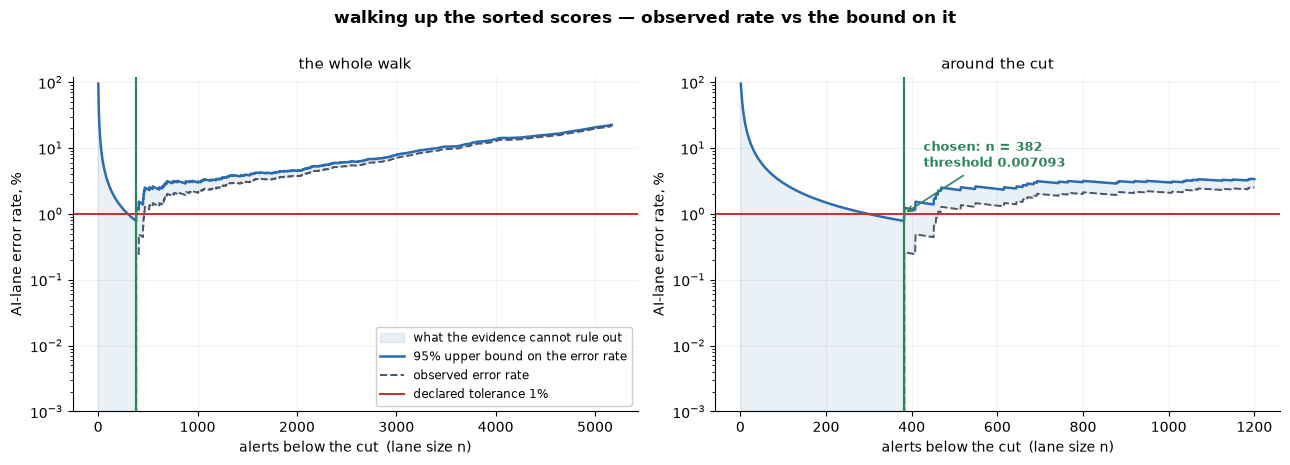

chosen lane        n = 382  (7.39% of the window)
  misses behind it     0
  observed rate        0.000%
  95% upper bound      0.781%   (tolerance 1.00%)
  THRESHOLD            0.007093


In [14]:
misses   = np.cumsum(sy)
observed = misses / rank
bound    = np.where(misses >= rank, 1.0, beta.ppf(CONFIDENCE, misses + 1, rank - misses))

ok      = bound <= TOLERANCE
chosen  = int(rank[ok].max()) if ok.any() else 0
cut     = float(ss[chosen - 1])
naive   = first_miss - 1                                   # the zero-miss answer

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, upto in ((axes[0], len(rank)), (axes[1], min(1200, len(rank)))):
    ax.fill_between(rank[:upto], observed[:upto] * 100, bound[:upto] * 100,
                    color="#2b6cb0", alpha=0.10,
                    label="what the evidence cannot rule out")
    ax.plot(rank[:upto], bound[:upto] * 100, color="#2b6cb0", lw=1.8,
            label="95% upper bound on the error rate")
    ax.plot(rank[:upto], observed[:upto] * 100, color="#4a5568", lw=1.4, ls="--",
            label="observed error rate")
    ax.axhline(TOLERANCE * 100, color="#c53030", lw=1.4,
               label=f"declared tolerance {TOLERANCE:.0%}")
    ax.axvline(chosen, color="#2f855a", lw=1.6)
    ax.set_yscale("log"); ax.set_ylim(1e-3, 120)
    ax.set_xlabel("alerts below the cut  (lane size n)")
    ax.set_ylabel("AI-lane error rate, %")
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(loc="lower right", fontsize=8.5, framealpha=0.95)
axes[1].annotate(f"chosen: n = {chosen:,}\nthreshold {cut:.6f}",
                 xy=(chosen, TOLERANCE * 100), xytext=(14, 34),
                 textcoords="offset points", fontsize=9.5, color="#2f855a",
                 fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color="#2f855a", lw=1.2))
axes[0].set_title("the whole walk", fontsize=11)
axes[1].set_title("around the cut", fontsize=11)
fig.suptitle("walking up the sorted scores — observed rate vs the bound on it",
             fontsize=12, fontweight="bold", y=1.0)
fig.tight_layout(); plt.show()

print(f"chosen lane        n = {chosen:,}  ({chosen / len(ss) * 100:.2f}% of the window)")
print(f"  misses behind it     {int(misses[chosen - 1])}")
print(f"  observed rate        {observed[chosen - 1] * 100:.3f}%")
print(f"  95% upper bound      {bound[chosen - 1] * 100:.3f}%   (tolerance {TOLERANCE * 100:.2f}%)")
print(f"  THRESHOLD            {cut:.6f}")


## Step 3 — why "zero mistakes" is not zero risk

This is the step that makes the whole thing necessary, so it is worth one figure
on its own.

Suppose a lane of `n` alerts closed with **no** mistake at all. The observed
error rate is 0%. The true rate is not — a coin that comes up heads 85 times has
not proved it never comes up tails. With zero failures in `n` trials the 95%
upper bound is about **3/n**, the *rule of three*, and it falls off slowly:

> a perfectly clean lane of 85 alerts still bounds the true error rate at
> **3.5%**, not at 0.

That is not a theoretical worry. The naive zero-miss threshold, chosen on one
window, let alerts through on the next, and **failed on three of six rolling
windows**. The curve below is why — it says exactly how much clean evidence a
claim of a given size requires.


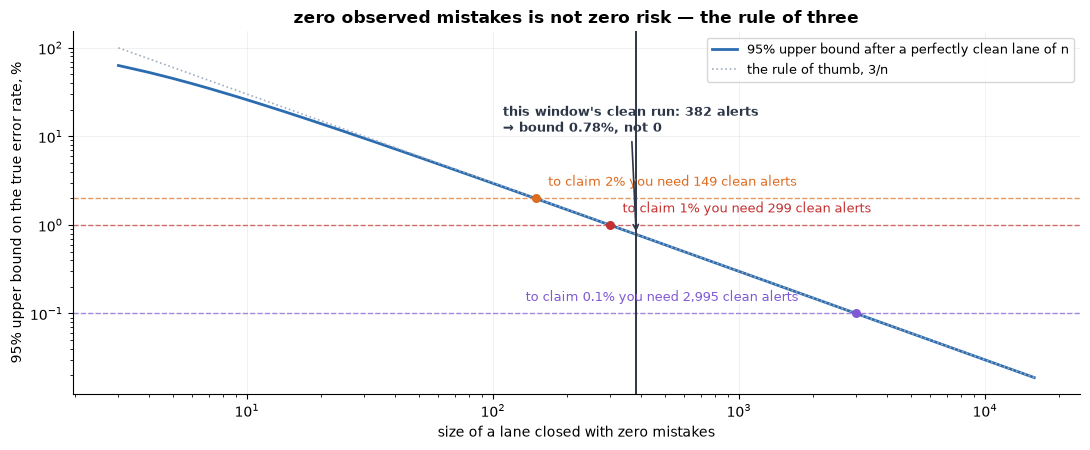

the 0.1% claim needs a clean lane of 2,995 — this window supplies 5,169 alerts in total, so 1% is the floor this much data can certify.


In [15]:
n_axis = np.unique(np.logspace(0.6, 4.2, 400).astype(int))
rule3  = np.array([beta.ppf(CONFIDENCE, 1, n) for n in n_axis])

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(n_axis, rule3 * 100, color="#2b6cb0", lw=2,
        label="95% upper bound after a perfectly clean lane of n")
ax.plot(n_axis, 300 / n_axis, color="#a0aec0", lw=1.2, ls=":",
        label="the rule of thumb, 3/n")

for claim, colour in ((2.0, "#dd6b20"), (1.0, "#c53030"), (0.1, "#805ad5")):
    need = int(np.ceil(np.log(1 - CONFIDENCE) / np.log(1 - claim / 100)))
    ax.axhline(claim, color=colour, lw=1, ls="--", alpha=0.7)
    side = (-238, 9) if claim < 0.5 else (9, 9)
    ax.annotate(f"to claim {claim:g}% you need {need:,} clean alerts",
                xy=(need, claim), xytext=side, textcoords="offset points",
                fontsize=9, color=colour)
    ax.scatter([need], [claim], s=30, color=colour, zorder=5)

ax.axvline(naive, color="#2d3748", lw=1.4)
ax.annotate(f"this window's clean run: {naive:,} alerts\n"
            f"→ bound {beta.ppf(CONFIDENCE, 1, naive) * 100:.2f}%, not 0",
            xy=(naive, beta.ppf(CONFIDENCE, 1, naive) * 100), xytext=(-96, 74),
            textcoords="offset points", fontsize=9.5, color="#2d3748",
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#2d3748", lw=1.2))

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("size of a lane closed with zero mistakes")
ax.set_ylabel("95% upper bound on the true error rate, %")
ax.set_title("zero observed mistakes is not zero risk — the rule of three",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.25, linewidth=0.5)
ax.legend(loc="upper right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

print(f"the 0.1% claim needs a clean lane of "
      f"{int(np.ceil(np.log(1 - CONFIDENCE) / np.log(1 - 0.001))):,} — "
      f"this window supplies {len(ss):,} alerts in total, so 1% is the floor "
      f"this much data can certify.")


## Step 4 — the dial, and what it costs

`tolerance` is the only knob, and it is a business decision rather than a
technical one: *how often may the AI lane be wrong?* Everything else follows
from it.

Each row below is chosen on the **calibrate** window and then measured on the
**validate** window, which had no part in choosing it. The last column is the
one that matters: what the error rate actually turned out to be on alerts nobody
had seen.

Two things in that table are worth reading slowly.

**The top four rows are the window refusing to answer.** No cut in this
calibration window has a 95% bound under 0.5%, because doing so would need a
clean run of ~600 alerts and there are 382. `calibrate.py` falls back to the
lowest score, which closes essentially nothing — the honest response to *"prove
you are 99.9% right"* on this much data is "not with this window." That is the
same arithmetic as Step 3, seen from the other end.

**At 1% the measured rate came back 1.20%.** That is not a bug, it is the
method predicting its own failure rate honestly: a 95% bound is wrong one time
in twenty, and the population also moved between the two windows. A method that
never overshot its stated tolerance would be one that was not being honest about
uncertainty.


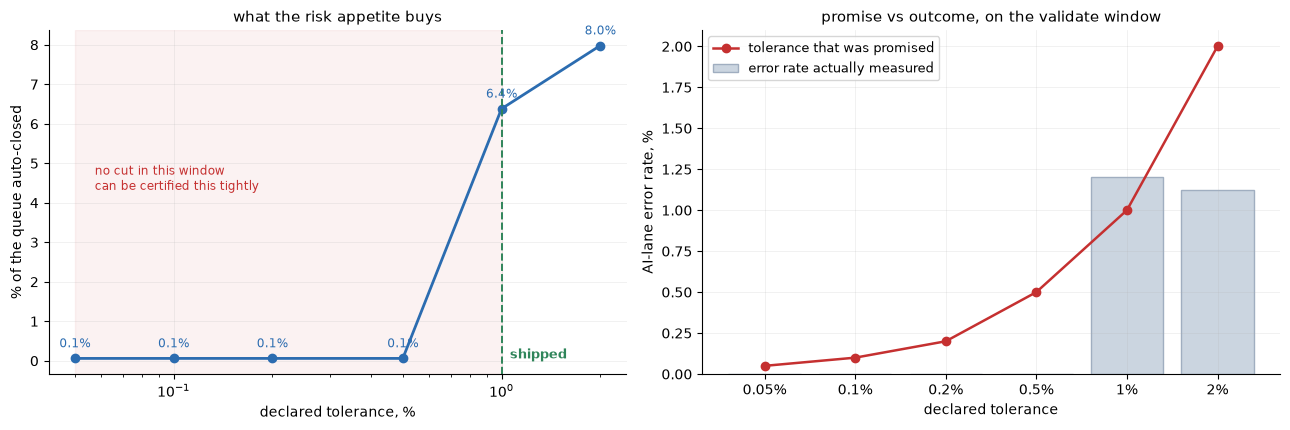

,tolerance_%,threshold,chosen_% (calibrate),auto-closed_% (validate),misses (validate),actual_error_% (validate)
0,0.05,0.000585,0.00,0.06,0,0.000
1,0.10,0.000585,0.00,0.06,0,0.000
2,0.20,0.000585,0.00,0.06,0,0.000
3,0.50,0.000585,0.00,0.06,0,0.000
4,1.00,0.007093,7.39,6.38,6,1.202
5,2.00,0.008012,8.92,7.98,7,1.122


In [16]:
def choose(y, score, tol):
    o = np.argsort(score, kind="mergesort")
    yy, sss = y[o], score[o]
    cum = np.cumsum(yy)
    r   = np.arange(1, len(yy) + 1)
    b   = np.where(cum >= r, 1.0, beta.ppf(CONFIDENCE, cum + 1, r - cum))
    fits = b <= tol
    if not fits.any():
        return 0, float(sss[0])
    n = int(r[fits].max())
    return n, float(sss[n - 1])

rows = []
for tol in (0.0005, 0.001, 0.002, 0.005, 0.01, 0.02):
    n, thr = choose(y_cal, s_cal, tol)
    lane = s_val < thr
    rows.append({
        "tolerance_%": tol * 100,
        "threshold": round(thr, 6),
        "chosen_% (calibrate)": round(n / len(s_cal) * 100, 2),
        "auto-closed_% (validate)": round(float(lane.mean() * 100), 2),
        "misses (validate)": int(y_val[lane].sum()),
        "actual_error_% (validate)": round(float(y_val[lane].mean() * 100), 3) if lane.sum() else 0.0,
    })
dial = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
ax1.plot(dial["tolerance_%"], dial["auto-closed_% (validate)"], marker="o",
         color="#2b6cb0", lw=2)
for x, y in zip(dial["tolerance_%"], dial["auto-closed_% (validate)"]):
    ax1.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8.5, color="#2b6cb0")
floor = dial.loc[dial["chosen_% (calibrate)"] > 0, "tolerance_%"].min()
ax1.axvspan(dial["tolerance_%"].min(), floor, color="#c53030", alpha=0.06)
ax1.text(dial["tolerance_%"].min() * 1.15, ax1.get_ylim()[1] * 0.55,
         "no cut in this window\ncan be certified this tightly",
         fontsize=8.5, color="#c53030", va="center")
ax1.axvline(TOLERANCE * 100, color="#2f855a", lw=1.4, ls="--")
ax1.annotate("shipped", xy=(TOLERANCE * 100, dial["auto-closed_% (validate)"].min()),
             xytext=(6, 0), textcoords="offset points", fontsize=9,
             color="#2f855a", fontweight="bold")
ax1.set_xscale("log"); ax1.set_xlabel("declared tolerance, %")
ax1.set_ylabel("% of the queue auto-closed")
ax1.set_title("what the risk appetite buys", fontsize=11)

ax2.bar(range(len(dial)), dial["actual_error_% (validate)"], color="#cbd5e0",
        edgecolor="#a0aec0", label="error rate actually measured")
ax2.plot(range(len(dial)), dial["tolerance_%"], marker="o", color="#c53030",
         lw=1.8, label="tolerance that was promised")
ax2.set_xticks(range(len(dial)))
ax2.set_xticklabels([f"{t:g}%" for t in dial["tolerance_%"]])
ax2.set_xlabel("declared tolerance")
ax2.set_ylabel("AI-lane error rate, %")
ax2.set_title("promise vs outcome, on the validate window", fontsize=11)
ax2.legend(fontsize=9)
for ax in (ax1, ax2):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

dial


## The cut, on data that had no part in choosing it

The last picture: the validate window's scores, with the shipped line drawn
through them. Everything left of the line closes itself.


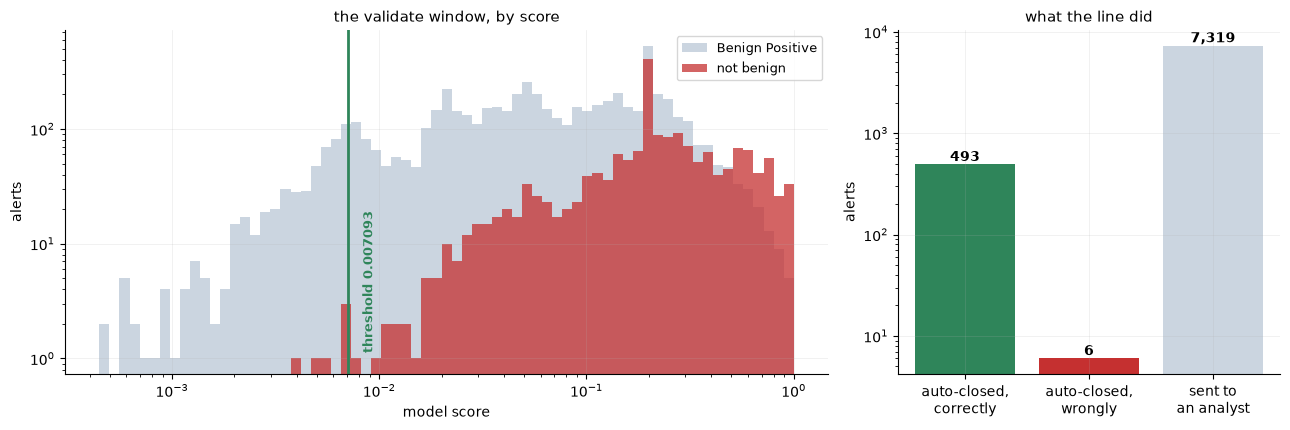

reproduced here : 0.007093
in the config   : 0.007093
auto-closed 6.38% of the validate window, 6 of them wrongly (1.20% of the AI lane)


In [17]:
shipped_cut = cut
edges = np.logspace(np.log10(max(s_val.min(), 1e-7)), 0, 70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4),
                               gridspec_kw={"width_ratios": [2, 1]})
ax1.hist(s_val[y_val == 0], bins=edges, color="#cbd5e0", label="Benign Positive")
ax1.hist(s_val[y_val == 1], bins=edges, color="#c53030", alpha=0.75,
         label="not benign")
ax1.axvline(shipped_cut, color="#2f855a", lw=2)
ax1.annotate(f"threshold {shipped_cut:.6f}", xy=(shipped_cut, 1),
             xytext=(10, 6), textcoords="offset points", rotation=90,
             fontsize=9, color="#2f855a", fontweight="bold")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("model score"); ax1.set_ylabel("alerts")
ax1.set_title("the validate window, by score", fontsize=11)
ax1.legend(fontsize=9)

lane = s_val < shipped_cut
counts = [int((lane & (y_val == 0)).sum()), int((lane & (y_val == 1)).sum()),
          int((~lane).sum())]
labels = ["auto-closed,\ncorrectly", "auto-closed,\nwrongly", "sent to\nan analyst"]
bars = ax2.bar(labels, counts, color=["#2f855a", "#c53030", "#cbd5e0"])
for b, c in zip(bars, counts):
    ax2.annotate(f"{c:,}", (b.get_x() + b.get_width() / 2, c), ha="center",
                 va="bottom", fontsize=10, fontweight="bold")
ax2.set_yscale("log"); ax2.set_ylabel("alerts")
ax2.set_title("what the line did", fontsize=11)
for ax in (ax1, ax2):
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

cfg_thr = yaml.safe_load((ML / "config" / "preprocessing.yaml").read_text())
cfg_thr = cfg_thr["operating_threshold"]["value"]
print(f"reproduced here : {shipped_cut:.6f}")
print(f"in the config   : {cfg_thr:.6f}")
print(f"auto-closed {lane.mean()*100:.2f}% of the validate window, "
      f"{counts[1]} of them wrongly "
      f"({counts[1] / max(lane.sum(), 1) * 100:.2f}% of the AI lane)")


---
### What this section is, and is not

One footnote on the arithmetic: the chosen threshold is the score of the *n*-th
alert, and the deployed rule is `score < threshold`, so the lane that actually
auto-closes is *n−1* alerts, not *n*. Off by one, in the safe direction.

**Is:** a defensible answer to "why *that* number?". The tolerance is a stated
risk appetite, the bound is exact, and the result is measured on a window that
had no part in choosing it. All three are recomputed by
`calibrate.py --write`, which is the only thing that should ever edit
`operating_threshold` in `config/preprocessing.yaml`.

**Is not:** a permanent answer. The threshold is perishable — the not-benign
rate ran 6.5% → 25.3% across this corpus, and a line drawn through last
quarter's scores stops meaning what it says. Recalibrate monthly. The model
itself does not need retraining for this; only the line moves.
